# Simple Autoencoder - Learning an Arbitrary Association
This notebook trains a simple convolutional autoencoder with a reconstruction objective (i.e. only compression, no denoising) on the MNIST dataset and then analyzes the representations in the network. This notebook is an initial baseline to build a "contextual" denoising autoencoder to demonstrate the proof of principle for a "visuo-tactile association" neuroscience experiment. This consists of adding a "contextual" input from another modality consistently paired with inputs of a given modality for a specific category: analyzing the representations in the network, and simulating a psychophysics experiment we aim at generating predictions for the real experiment.

In [1]:
# necessary imports
import sys
import os
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.spatial.distance import pdist, squareform
import torchvision.transforms as transforms
import torchvision.utils
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST

In [2]:
# check if cuda is available
cuda_enabled = torch.cuda.is_available()
# print result
print("CUDA is enabled:", cuda_enabled)
# additional information if CUDA is enabled
if cuda_enabled:
    print("CUDA device count:", torch.cuda.device_count())
    print("CUDA current device:", torch.cuda.current_device())
    print("CUDA device name:", torch.cuda.get_device_name(torch.cuda.current_device()))

CUDA is enabled: True
CUDA device count: 1
CUDA current device: 0
CUDA device name: NVIDIA RTX 2000 Ada Generation Laptop GPU


In [3]:
# set dark background for plots
plt.style.use('dark_background')

### MNIST Data Loading
MNIST images show digits from 0-9 in 28x28 grayscale images. We normalize and center them around 0, which gives a slight performance boost during training. We create both a training set and a test set.

In [5]:
# set batch size
batch_size = 128
# define preprocessing image transformation for MNIST dataset
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
# load MNIST dataset, training set
train_dataset = MNIST(root='./data/MNIST', download=True, train=True, transform=img_transform)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# load MNIST dataset, testing set
test_dataset = MNIST(root='./data/MNIST', download=True, train=False, transform=img_transform)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

### Autoencoder Definition
We use a convolutional encoder and decoder, which generally gives better performance than fully connected versions that have the same number of parameters. In convolution layers, we increase the channels as we approach the bottleneck, but note that the total number of features still decreases, since the channels increase by a factor of 2 in each convolution, but the spatial size decreases by a factor of 4. Kernel size 4 is used to avoid biasing problems (see distill on checkerboard artifacts). Here we don't have any contextual input yet and the objective is just reconstruction, not denoising.

In [8]:
# set autoencoder parameters
latent_dims = 10
num_epochs = 50
capacity = 64
learning_rate = 1e-3
use_gpu = True

In [9]:
# define encoder class
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        c = capacity
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=c, kernel_size=4, stride=2, padding=1) # out: c x 14 x 14
        self.conv2 = nn.Conv2d(in_channels=c, out_channels=c*2, kernel_size=4, stride=2, padding=1) # out: c x 7 x 7
        self.fc = nn.Linear(in_features=c*2*7*7, out_features=latent_dims)
            
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1) # flatten batch of multi-channel feature maps to a batch of feature vectors
        x = self.fc(x)
        return x
    
# define decoder class
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        c = capacity
        self.fc = nn.Linear(in_features=latent_dims, out_features=c*2*7*7)
        self.conv2 = nn.ConvTranspose2d(in_channels=c*2, out_channels=c, kernel_size=4, stride=2, padding=1)
        self.conv1 = nn.ConvTranspose2d(in_channels=c, out_channels=1, kernel_size=4, stride=2, padding=1)
            
    def forward(self, x):
        x = self.fc(x)
        x = x.view(x.size(0), capacity*2, 7, 7) # unflatten batch of feature vectors to a batch of multi-channel feature maps
        x = F.relu(self.conv2(x))
        x = torch.tanh(self.conv1(x)) # last layer before output is tanh, since the images are normalized and 0-centered
        return x

# define full autoencoder class    
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()
    def forward(self, x):
        latent = self.encoder(x)
        x_recon = self.decoder(latent)
        return x_recon
    
# create autoencoder model    
autoencoder = Autoencoder()

# set device to GPU if available
device = torch.device("cuda:0" if use_gpu and torch.cuda.is_available() else "cpu")
autoencoder = autoencoder.to(device)

# ouput model information
num_params = sum(p.numel() for p in autoencoder.parameters() if p.requires_grad)
print('Number of parameters: %d' % num_params)

Number of parameters: 396171


Train the autoencoder on the MNIST dataset for a reconstruction task, where the goal is to reobtain the input image as output after compressing it in the latent space. By adding noise to the input during training, we could transform it into a denoising autoencoder, teaching it to reconstruct clean images from noisy inputs. Note that, in this setup, we don't include any contextual input yet.

In [12]:
# set retrain flag
retrain = False

# create the pretrained directory if it doesn't exist
pretrained_dir = './pretrained'
pretrained_path = os.path.join(pretrained_dir, 'my_autoencoder.pth')
if not os.path.isdir(pretrained_dir):
    os.makedirs(pretrained_dir)

# instantiate the autoencoder and move it to the GPU
autoencoder = Autoencoder()
autoencoder = autoencoder.to(device)

# check if retraining is required or if pretrained model is missing
if retrain or not os.path.isfile(pretrained_path):
    # define the optimizer (Adam optimizer)
    optimizer = torch.optim.Adam(params=autoencoder.parameters(), lr=learning_rate, weight_decay=1e-5)

    # set the model to training mode
    autoencoder.train()
    train_loss_avg = []

    print('Training ...')
    for epoch in range(num_epochs):
        train_loss_avg.append(0)
        num_batches = 0

        for image_batch, _ in train_dataloader:  # assume train_dataloader is already defined
            image_batch = image_batch.to(device)
            
            # autoencoder reconstruction
            image_batch_recon = autoencoder(image_batch)
            
            # compute reconstruction error
            loss = F.mse_loss(image_batch_recon, image_batch)
            
            # backpropagation
            optimizer.zero_grad()
            loss.backward()
            
            # optimizer step
            optimizer.step()
            
            train_loss_avg[-1] += loss.item()
            num_batches += 1

        # calculate average loss for the epoch
        train_loss_avg[-1] /= num_batches
        print('Epoch [%d / %d] average reconstruction error: %f' % (epoch + 1, num_epochs, train_loss_avg[-1]))

    # save the trained model
    torch.save(autoencoder.state_dict(), pretrained_path)
    print(f"Model saved to {pretrained_path}")

    # plot the training curve
    plt.ion()
    fig = plt.figure()
    plt.plot(train_loss_avg)
    plt.xlabel('Epochs')
    plt.ylabel('Reconstruction error')
    plt.show()
else:
    # load the pretrained model
    autoencoder.load_state_dict(torch.load(pretrained_path))
    print("Loaded pretrained model.")

Loaded pretrained model.


Test the trained autoencoder on reconstructing images in the test set.

In [13]:
# set to evaluation mode
autoencoder.eval()

# test the autoencoder
test_loss_avg, num_batches = 0, 0
for image_batch, _ in test_dataloader:
    
    with torch.no_grad():

        # get the inputs of the batch 
        image_batch = image_batch.to(device)

        # autoencoder reconstruction
        image_batch_recon = autoencoder(image_batch)

        # reconstruction error
        loss = F.mse_loss(image_batch_recon, image_batch)

        test_loss_avg += loss.item()
        num_batches += 1
    
# calculate the average reconstruction error    
test_loss_avg /= num_batches
print('average reconstruction error: %f' % (test_loss_avg))

average reconstruction error: 0.046998


Visualize reconstructions of images in the test set.

Original images


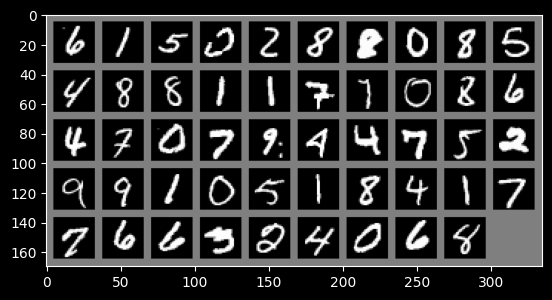

Autoencoder reconstruction:


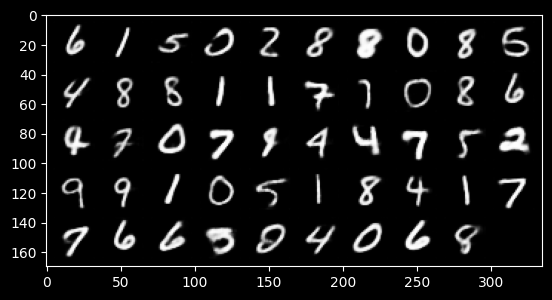

In [14]:
plt.ion()

# set to evaluation mode
autoencoder.eval()

# This function takes as an input the images to reconstruct
# and the name of the model with which the reconstructions are performed
def to_img(x):
    x = 0.5 * (x + 1)
    x = x.clamp(0, 1)
    return x

def show_image(img):
    img = to_img(img)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

def visualise_output(images, model):
    with torch.no_grad():
        images = images.to(device)
        images = model(images)
        images = images.cpu()
        images = to_img(images)
        np_imagegrid = torchvision.utils.make_grid(images[1:50], 10, 5).numpy()
        plt.imshow(np.transpose(np_imagegrid, (1, 2, 0)))
        plt.show()

images, labels = next(iter(test_dataloader))

# First visualise the original images
print('Original images')
show_image(torchvision.utils.make_grid(images[1:50], 10, 5))
plt.show()

# Reconstruct and visualise the images using the autoencoder
print('Autoencoder reconstruction:')
visualise_output(images, autoencoder)


Interpolate in latent space between two test images.

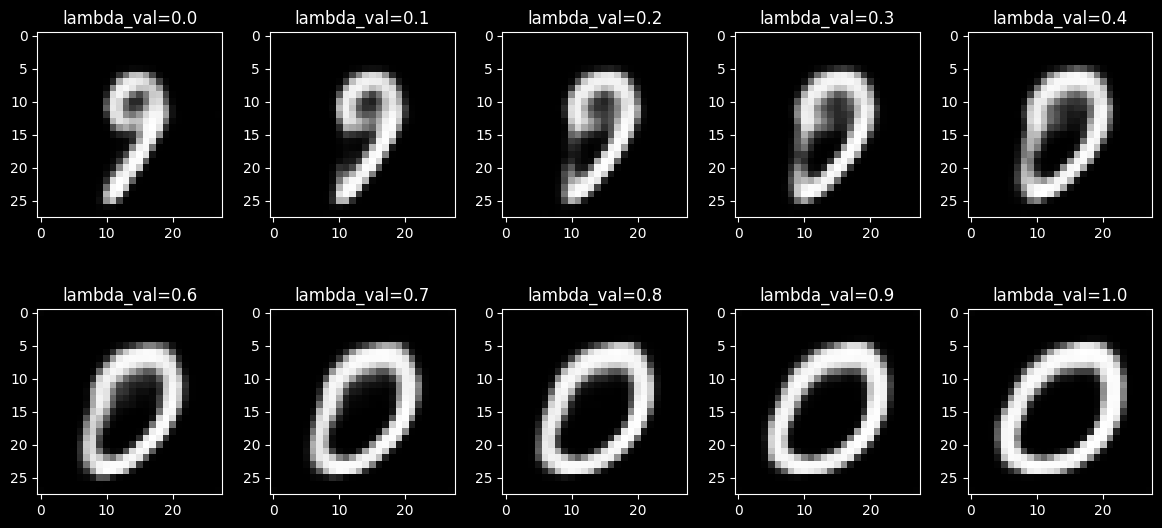

In [16]:
autoencoder.eval()

def interpolation(lambda1, model, img1, img2):
    
    with torch.no_grad():

        # latent vector of first image
        img1 = img1.to(device)
        latent_1 = model.encoder(img1)

        # latent vector of second image
        img2 = img2.to(device)
        latent_2 = model.encoder(img2)

        # interpolation of the two latent vectors
        inter_latent = lambda1 * latent_1 + (1- lambda1) * latent_2

        # reconstruct interpolated image
        inter_image = model.decoder(inter_latent)
        inter_image = inter_image.cpu()
    
    return inter_image
    
# sort part of test set by digit
digits = [[] for _ in range(10)]
for img_batch, label_batch in test_dataloader:
    for i in range(img_batch.size(0)):
        digits[label_batch[i]].append(img_batch[i:i+1])
    if sum(len(d) for d in digits) >= 1000:
        break

# interpolation lambdas
lambda_range=np.linspace(0,1,10)

fig, axs = plt.subplots(2,5, figsize=(15, 6))
fig.subplots_adjust(hspace = .5, wspace=.001)
axs = axs.ravel()

for ind,l in enumerate(lambda_range):
    inter_image=interpolation(float(l), autoencoder, digits[1][0], digits[7][0])
   
    inter_image = to_img(inter_image)
    
    image = inter_image.numpy()
   
    axs[ind].imshow(image[0,0,:,:], cmap='gray')
    axs[ind].set_title('lambda_val='+str(round(l,1)))

plt.show() 

### Random Latent Vector Sampling (Autoencoder as Generator)

In this approach, latent vectors are sampled from a multivariate normal distribution, approximated to match the distribution of encoded latent vectors of the data. By sampling from this fitted normal distribution, we aim to remain within the region of latent space that the autoencoder typically encounters during training. However, even with this approach, generating clear, valid digits is inconsistent: many sampled latent vectors still decode into outputs that resemble noise rather than recognisable digits. This indicates that the latent vectors corresponding to valid digits form a sparse, structured manifold within the latent space, and this sparsity increases with higher-dimensional latent spaces. This contrasts with Variational Autoencoders (VAEs), which enforce a more continuous and well-defined latent space structure, enabling them to generate valid digits more reliably from random samples. This example demonstrates that without such constraints, a standard autoencoder may struggle to generate meaningful outputs from random latent vectors, even if those vectors are sampled from a distribution aligned with the data.

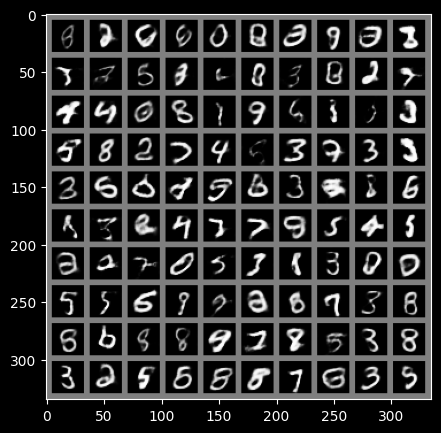

In [17]:
# set to evaluation mode
autoencoder.eval()

with torch.no_grad():
    # approx. fit a multivariate Normal distribution (with diagonal cov.) to the latent vectors of a random part of the test set
    images, labels = next(iter(test_dataloader))
    images = images.to(device)
    latent = autoencoder.encoder(images)
    latent = latent.cpu()

    mean = latent.mean(dim=0)
    std = (latent - mean).pow(2).mean(dim=0).sqrt()

    # sample latent vectors from the normal distribution
    latent = torch.randn(128, latent_dims)*std + mean

    # reconstruct images from the latent vectors
    latent = latent.to(device)
    img_recon = autoencoder.decoder(latent)
    img_recon = img_recon.cpu()

    fig, ax = plt.subplots(figsize=(5, 5))
    show_image(torchvision.utils.make_grid(img_recon[:100],10,5))
    plt.show()

### Visualising Activations with t-SNE and Representation Dissimilarity Matrices (RDMs)

In this section, we explore the internal representations learned by an autoencoder model at various layers, using two primary tools:

1. **t-SNE Visualisations**: t-SNE (t-Distributed Stochastic Neighbour Embedding) is a dimensionality reduction technique that helps visualise high-dimensional data in a 2D space. By applying t-SNE to the activations from different layers (input pixel space, convolutional layers, and the latent space), we can observe how different digit classes are clustered at each stage. Each digit is represented by a distinct colour, and each point is annotated with its respective digit label to aid in interpreting the clusters.

2. **Representation Dissimilarity Matrices (RDMs)**: RDMs are matrices that quantify the pairwise dissimilarities between activation patterns across samples. For each layer, we calculate the RDM using Euclidean distances between activation vectors. The RDMs are ordered by digit class, creating a block structure that reflects within-class similarity and between-class dissimilarity. This approach allows us to measure and compare how well-separated different digit classes are across the network layers. We also compute the average within-cluster and across-cluster distances and display these values in the RDM titles.

Implementation Details:

- **Layer-wise Activation Hooks**: We set up hooks on selected layers of the encoder to capture activations as the test images pass through the network.
- **t-SNE Plotting**: For each layer, we apply t-SNE to a balanced sample from each digit class and display the 2D projections in a scatter plot. Points are annotated with their digit labels to facilitate interpretation.
- **RDM Calculation and Visualisation**: For each layer, we compute the RDM using pairwise Euclidean distances on sorted activations. Separator lines and digit labels are added to highlight the block structure. The resulting RDMs reveal how separable the different classes are within each layer.

By examining these visualisations, we can gain insights into how the autoencoder organizes information about different digit classes at various levels of abstraction, from raw pixel values to the latent space. This approach also allows for future analyses, such as the effect of adding perturbations or noise to latent representations.


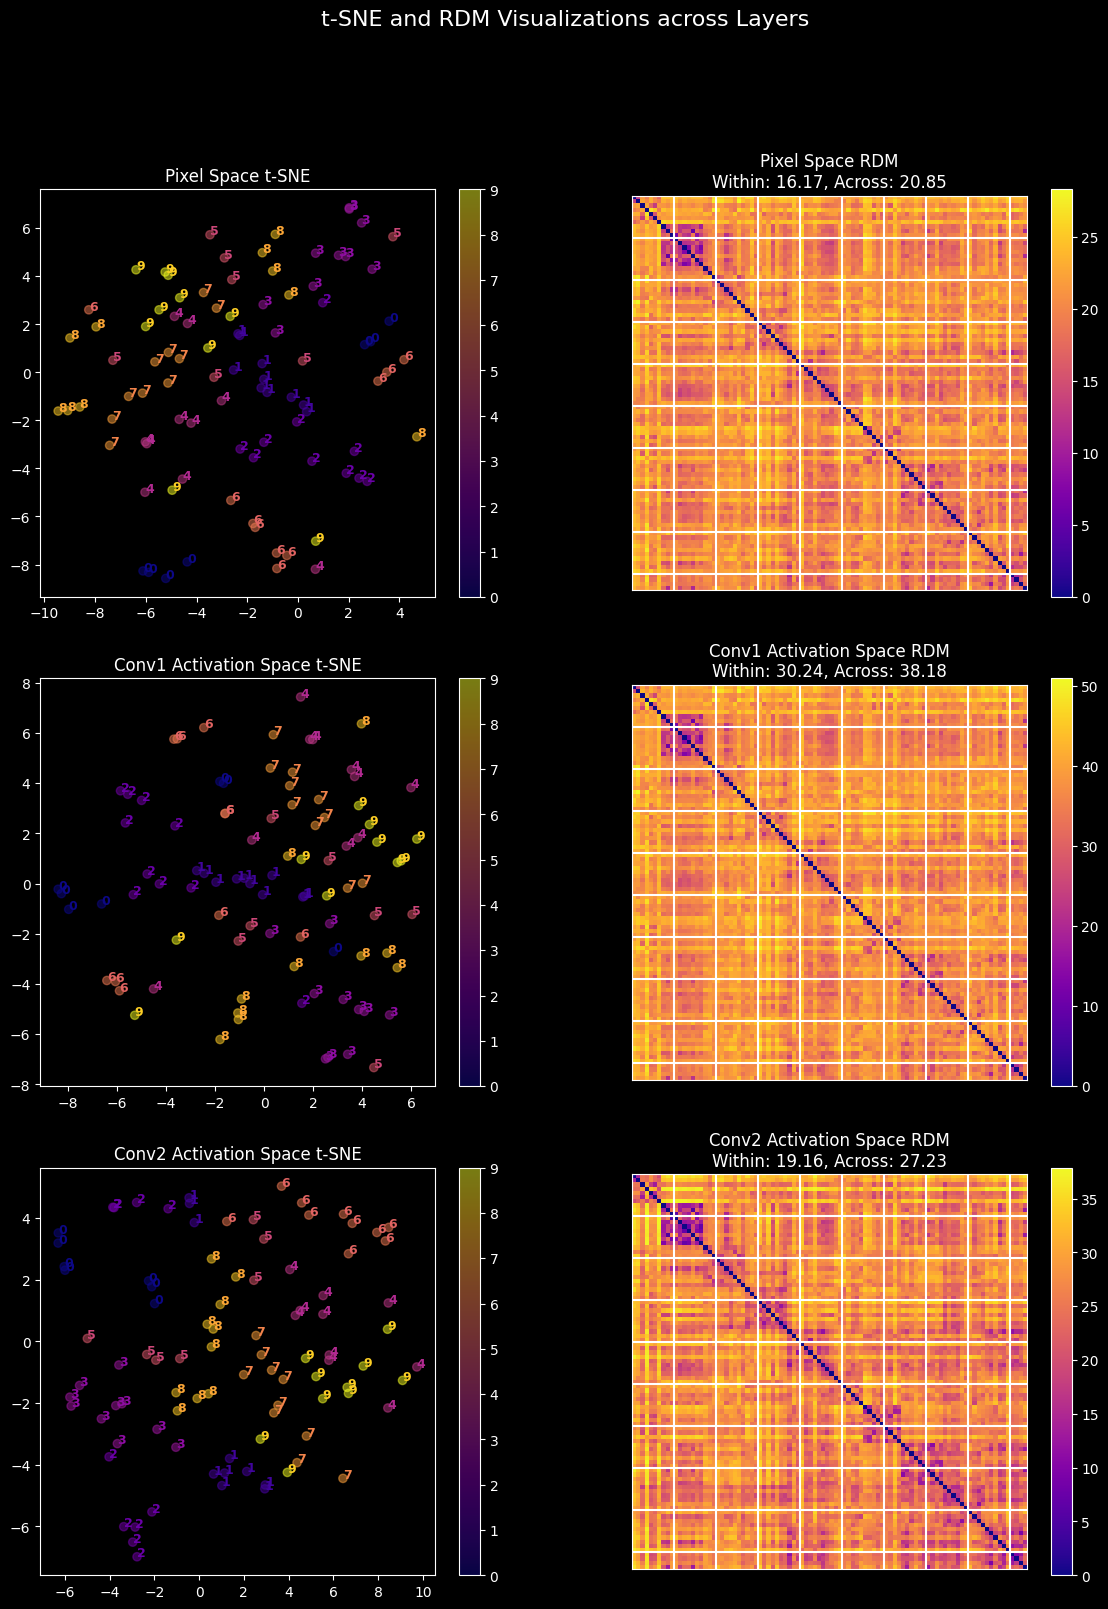

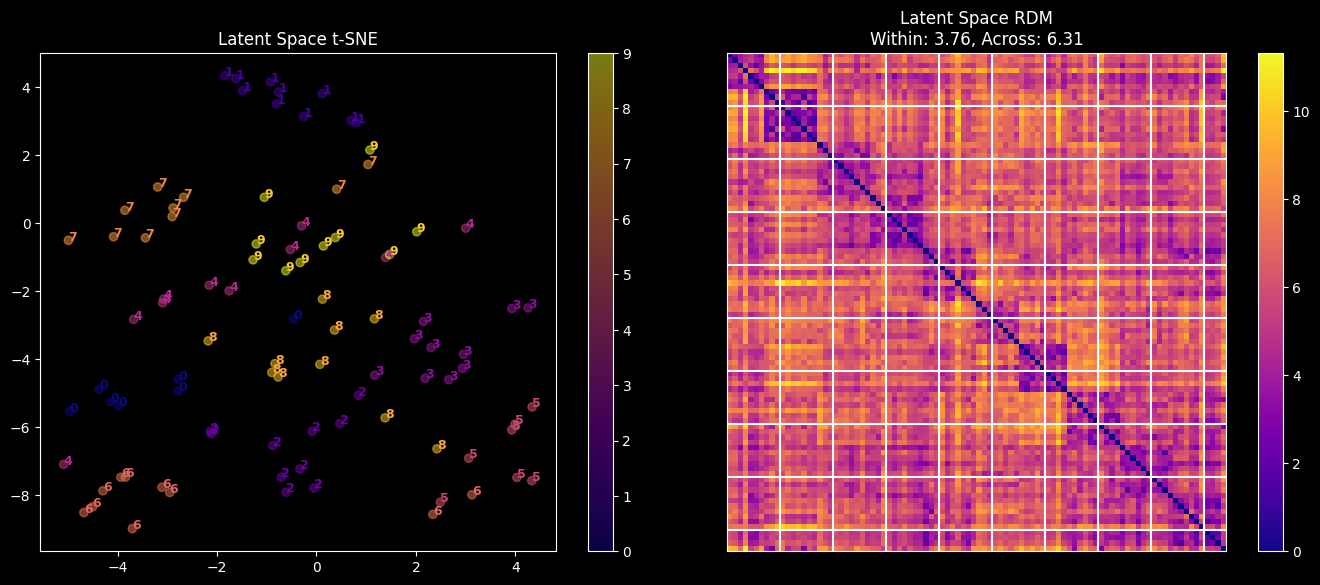

In [18]:
# set the model to evaluation mode
autoencoder.eval()

# define dictionaries to store the activations
activations = {'conv1': [], 'conv2': [], 'latent': []}

# hook functions to capture activations from each layer
def hook_conv1(module, input, output):
    activations['conv1'].append(output.detach().cpu().numpy())

def hook_conv2(module, input, output):
    activations['conv2'].append(output.detach().cpu().numpy())

def hook_latent(module, input, output):
    activations['latent'].append(output.detach().cpu().numpy())

# register hooks to the layers in the encoder
autoencoder.encoder.conv1.register_forward_hook(hook_conv1)
autoencoder.encoder.conv2.register_forward_hook(hook_conv2)
autoencoder.encoder.fc.register_forward_hook(hook_latent)

# process a batch of test images
data_iter = iter(test_dataloader)
images, labels = next(data_iter)
images = images.to(device)

# run the batch through the autoencoder to capture activations
_ = autoencoder(images)

# convert activation lists to numpy arrays for visualization
for key in activations:
    activations[key] = np.concatenate(activations[key], axis=0)

# helper function for t-SNE and visualization
def plot_tsne_and_rdm(activation, labels, title, ax_tsne, ax_rdm, num_samples_per_class=10):
    # subsample activation and labels to have a balanced number of samples per class
    selected_indices = np.concatenate([np.where(labels == i)[0][:num_samples_per_class] for i in range(10)])
    selected_activation = activation[selected_indices]
    selected_labels = labels[selected_indices]
    
    # compute t-SNE
    tsne = TSNE(n_components=2, random_state=0)
    reduced_data = tsne.fit_transform(selected_activation.reshape(selected_activation.shape[0], -1))
    
    # t-SNE scatter plot with digit annotations
    ax_tsne.set_title(f'{title} t-SNE')
    for i, (x, y) in enumerate(reduced_data):
        ax_tsne.text(x, y, str(selected_labels[i]), color=plt.cm.plasma(selected_labels[i] / 10), 
                     fontdict={'weight': 'bold', 'size': 9})
    scatter = ax_tsne.scatter(reduced_data[:, 0], reduced_data[:, 1], c=selected_labels, cmap='plasma', alpha=0.5)
    ax_tsne.figure.colorbar(scatter, ax=ax_tsne, ticks=range(10))
    
    # compute the RDM
    sorted_indices = np.argsort(selected_labels)
    sorted_activation = selected_activation[sorted_indices]
    sorted_labels = selected_labels[sorted_indices]
    rdm = squareform(pdist(sorted_activation.reshape(sorted_activation.shape[0], -1), 'euclidean'))
    
    # calculate within-cluster and across-cluster distances
    within_distances = []
    across_distances = []
    for i in range(10):
        indices = np.where(sorted_labels == i)[0]
        other_indices = np.where(sorted_labels != i)[0]
        if len(indices) > 1:
            within_distances.append(np.mean(rdm[np.ix_(indices, indices)]))
        if len(indices) > 0 and len(other_indices) > 0:
            across_distances.append(np.mean(rdm[np.ix_(indices, other_indices)]))
    avg_within_distance = np.mean(within_distances)
    avg_across_distance = np.mean(across_distances)
    
    # plot the RDM with separators and labels
    rdm_plot = ax_rdm.imshow(rdm, cmap='plasma', interpolation='nearest')
    ax_rdm.set_title(f'{title} RDM\nWithin: {avg_within_distance:.2f}, Across: {avg_across_distance:.2f}')
    ax_rdm.figure.colorbar(rdm_plot, ax=ax_rdm)
    
    # add separator lines and digit labels in white with quotation marks
    class_size = num_samples_per_class
    for i in range(10):
        ax_rdm.axhline(i * class_size - 0.5, color='white', linewidth=1.5)
        ax_rdm.axvline(i * class_size - 0.5, color='white', linewidth=1.5)
        ax_rdm.text(-2.5, i * class_size + class_size / 2 - 0.5, f'"{i}"', va='center', ha='right', fontsize=10, color='black')
        ax_rdm.text(i * class_size + class_size / 2 - 0.5, sorted_labels.size + 2, f'"{i}"', va='center', ha='center', fontsize=10, color='black')

    ax_rdm.set_xticks([])
    ax_rdm.set_yticks([])

# set up the figure with subplots
fig, axs = plt.subplots(3, 2, figsize=(14, 18))
fig.suptitle("t-SNE and RDM Visualizations across Layers", fontsize=16)

# pixel space t-SNE and RDM
plot_tsne_and_rdm(images.view(images.size(0), -1).cpu().numpy(), labels.numpy(), "Pixel Space", axs[0, 0], axs[0, 1])

# conv1 t-SNE and RDM
plot_tsne_and_rdm(activations['conv1'], labels.numpy(), "Conv1 Activation Space", axs[1, 0], axs[1, 1])

# conv2 t-SNE and RDM
plot_tsne_and_rdm(activations['conv2'], labels.numpy(), "Conv2 Activation Space", axs[2, 0], axs[2, 1])

# latent space t-SNE and RDM
fig, (ax_tsne, ax_rdm) = plt.subplots(1, 2, figsize=(14, 6))
plot_tsne_and_rdm(activations['latent'], labels.numpy(), "Latent Space", ax_tsne, ax_rdm)

# show the plots
plt.tight_layout(pad=2)
plt.show()

### TODO List: Experimental Ideas for Model Analysis

1. **Train a Decoder**
   - Train a decoder to classify the digit from the latent vector representation.
   - Use this decoder to:
     - **Interpolate and Reconstruct**: Reconstruct images at various levels of interpolation between latent vectors of different digits.
     - **Noise Testing**: Feed the interpolated images back into the network with added noise and assess the model's classification accuracy.
     - **Neurometric Functions**: Analyse the resulting neurometric functions to determine if they exhibit linear or nonlinear characteristics.

2. **Build and Analyse a Confusion Matrix**
   - Construct a confusion matrix based on the decoder’s predictions to understand classification accuracy and error patterns.
   - **Modified Training**:
     - Add an extra feature (e.g., a pixel always "on" in one corner) to all training examples of a specific class.
     - **Test Generalisation**: At test time, observe if adding this feature to any digit’s latent vector influences classification by increasing the likelihood of misclassification toward the class associated with the feature.
     - **t-SNE flow field**: Also show flow field of how representation moves in original t-SNE space for all digits when retraining the association and pairing the pixel always "on" perturbation (they should all flow towards the associated digit).

---

**Note**: It would also be valuable to test the impact of this single-pixel perturbation on the non-retrained autoencoder as a control. This could provide insights into the robustness of the original model to subtle input modifications and help differentiate effects due to the feature from those due to retraining.
